# Projeto 1: Baseline de Regressão Linear

**Objetivo:** construir um baseline de regressão linear para prever `charges` usando as variáveis mais relevantes identificadas no EDA.

**Decisões herdadas do EDA:**
- usar `age`, `bmi` e `smoker` como conjunto inicial de features;
- remover a duplicata exata encontrada no dataset;
- comparar o baseline na escala original de `charges` e na escala `log1p(charges)`;
- avaliar principalmente por `RMSE`, sem perder a leitura dos coeficientes e dos resíduos.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
df = pd.read_csv("../data/insurance.csv").drop_duplicates().copy()
df["smoker_yes"] = (df["smoker"] == "yes").astype(int)

features = ["age", "bmi", "smoker_yes"]
target = "charges"

print(f"Linhas após remover duplicatas: {df.shape[0]}")
print(f"Features do baseline: {features}")

df[features + [target]].head()

Linhas após remover duplicatas: 1337
Features do baseline: ['age', 'bmi', 'smoker_yes']


,age,bmi,smoker_yes,charges
0,19,27.9000,1,"16,884.9240"
1,18,33.7700,0,"1,725.5523"
2,28,33.0000,0,"4,449.4620"
3,33,22.7050,0,"21,984.4706"
4,32,28.8800,0,"3,866.8552"


## 1. Separação entre treino e teste

Como `smoker` é a variável mais importante e a classe positiva é minoritária, usamos `stratify` nessa coluna para preservar sua proporção entre treino e teste.


In [3]:
X = df[features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=df["smoker_yes"]
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")
print("\nProporção de fumantes no dataset completo:", df["smoker_yes"].mean().round(4))
print("Proporção de fumantes no treino:", X_train["smoker_yes"].mean().round(4))
print("Proporção de fumantes no teste:", X_test["smoker_yes"].mean().round(4))

Treino: (1069, 3)
Teste: (268, 3)

Proporção de fumantes no dataset completo: 0.2049
Proporção de fumantes no treino: 0.2049
Proporção de fumantes no teste: 0.2052


In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def regression_metrics(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


def metrics_table(train_true, train_pred, test_true, test_pred, model_name, scale_label):
    train_metrics = regression_metrics(train_true, train_pred)
    test_metrics = regression_metrics(test_true, test_pred)

    return pd.DataFrame([
        {
            "modelo": model_name,
            "split": "train",
            "escala": scale_label,
            **train_metrics
        },
        {
            "modelo": model_name,
            "split": "test",
            "escala": scale_label,
            **test_metrics
        }
    ])


def coefficient_table(ols_model):
    conf = ols_model.conf_int()
    return pd.DataFrame({
        "feature": ols_model.params.index,
        "coef": ols_model.params.values,
        "p_value": ols_model.pvalues.values,
        "ci_2.5%": conf[0].values,
        "ci_97.5%": conf[1].values
    })

## 2. Baseline linear na escala original de `charges`

Esse é o modelo mais direto para leitura de coeficientes em reais. A interpretação é: mantendo as demais variáveis constantes, quanto `charges` varia em média quando uma feature aumenta uma unidade.


In [5]:
model_raw = LinearRegression()
model_raw.fit(X_train, y_train)

pred_train_raw = model_raw.predict(X_train)
pred_test_raw = model_raw.predict(X_test)

raw_metrics = metrics_table(
    y_train,
    pred_train_raw,
    y_test,
    pred_test_raw,
    model_name="Linear (charges)",
    scale_label="charges"
)

display(raw_metrics)

,modelo,split,escala,RMSE,MAE,R2
0,Linear (charges),train,charges,"6,329.3621","4,383.7755",0.7277
1,Linear (charges),test,charges,"5,002.2242","3,592.7740",0.8264


In [6]:
X_train_sm = sm.add_constant(X_train)
ols_raw = sm.OLS(y_train, X_train_sm).fit()
coef_raw = coefficient_table(ols_raw)

display(coef_raw)

,feature,coef,p_value,ci_2.5%,ci_97.5%
0,const,"-11,132.6907",0.0000,"-13,295.5873","-8,969.7941"
1,age,259.0895,0.0000,231.8428,286.3361
2,bmi,308.6324,0.0000,245.7679,371.4968
3,smoker_yes,"23,696.6607",0.0000,"22,753.2138","24,640.1076"


,charges_real,charges_predito,residuo
0,"12,222.8983","12,280.0400",-57.1417
1,"10,096.9700","8,748.1400","1,348.8300"
2,"41,999.5200","36,060.6783","5,938.8417"
3,"20,745.9891","29,191.3167","-8,445.3276"
4,"4,766.0220","3,126.9606","1,639.0614"
5,"7,173.3600","6,238.3860",934.9739
6,"1,880.0700","4,233.9668","-2,353.8968"
7,"11,253.4210","11,425.9370",-172.5160
8,"9,504.3103","15,398.0355","-5,893.7252"
9,"8,596.8278","9,564.0615",-967.2337


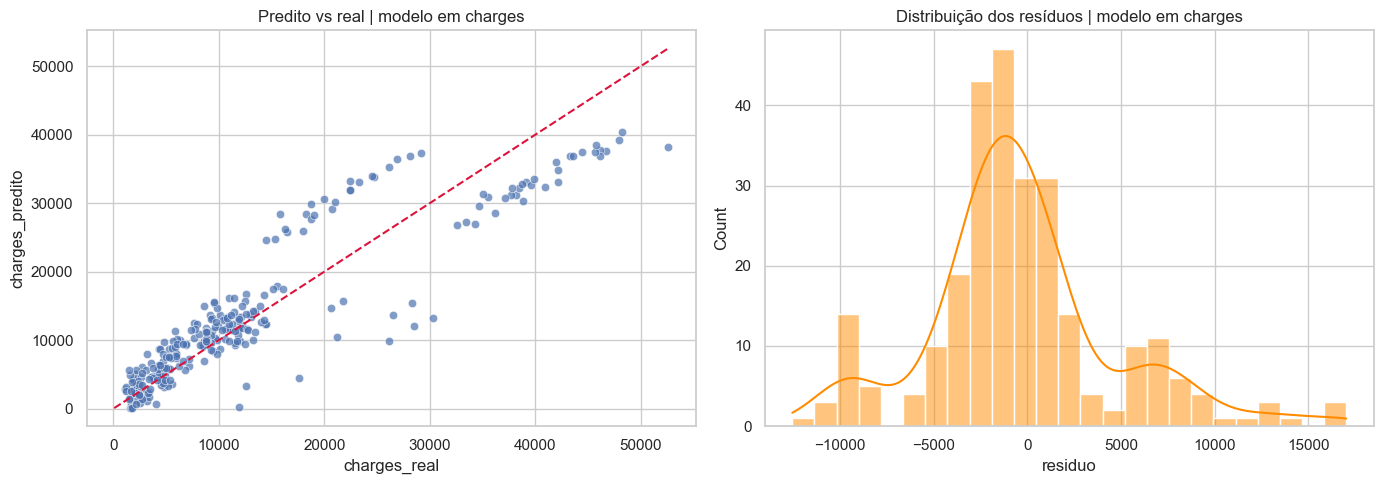

In [7]:
raw_predictions = pd.DataFrame({
    "charges_real": y_test,
    "charges_predito": pred_test_raw,
    "residuo": y_test - pred_test_raw
}).reset_index(drop=True)

display(raw_predictions.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=raw_predictions, x="charges_real", y="charges_predito", ax=axes[0], alpha=0.7)
min_raw = min(raw_predictions["charges_real"].min(), raw_predictions["charges_predito"].min())
max_raw = max(raw_predictions["charges_real"].max(), raw_predictions["charges_predito"].max())
axes[0].plot([min_raw, max_raw], [min_raw, max_raw], color="crimson", linestyle="--")
axes[0].set_title("Predito vs real | modelo em charges")

sns.histplot(raw_predictions["residuo"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribuição dos resíduos | modelo em charges")

plt.tight_layout()
plt.show()

## 3. Baseline linear na escala `log1p(charges)`

Aqui treinamos o mesmo conjunto de features, mas com a target transformada. Isso tende a suavizar assimetria e reduzir o peso relativo dos outliers. Depois, voltamos as previsões para a escala original para comparar `RMSE` e `R²` em `charges`.


In [8]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model_log = LinearRegression()
model_log.fit(X_train, y_train_log)

pred_train_log = model_log.predict(X_train)
pred_test_log = model_log.predict(X_test)

pred_train_log_back = np.expm1(pred_train_log)
pred_test_log_back = np.expm1(pred_test_log)

log_metrics = metrics_table(
    y_train_log,
    pred_train_log,
    y_test_log,
    pred_test_log,
    model_name="Linear (log1p)",
    scale_label="log1p(charges)"
)

log_back_metrics = metrics_table(
    y_train,
    pred_train_log_back,
    y_test,
    pred_test_log_back,
    model_name="Linear (log1p -> charges)",
    scale_label="charges"
)

display(log_metrics)
display(log_back_metrics)

,modelo,split,escala,RMSE,MAE,R2
0,Linear (log1p),train,log1p(charges),0.4841,0.3154,0.7227
1,Linear (log1p),test,log1p(charges),0.3768,0.2537,0.8297


,modelo,split,escala,RMSE,MAE,R2
0,Linear (log1p -> charges),train,charges,"8,368.2534","4,404.0837",0.5240
1,Linear (log1p -> charges),test,charges,"7,818.6976","3,841.8216",0.5759


In [9]:
ols_log = sm.OLS(y_train_log, X_train_sm).fit()
coef_log = coefficient_table(ols_log)

display(coef_log)

,feature,coef,p_value,ci_2.5%,ci_97.5%
0,const,7.1634,0.0000,6.9980,7.3288
1,age,0.0347,0.0000,0.0326,0.0367
2,bmi,0.0089,0.0003,0.0041,0.0137
3,smoker_yes,1.5403,0.0000,1.4682,1.6125


,charges_real,charges_predito,residuo
0,"12,222.8983","12,269.2428",-46.3445
1,"10,096.9700","7,996.2116","2,100.7584"
2,"41,999.5200","51,473.5956","-9,474.0756"
3,"20,745.9891","21,987.3957","-1,241.4066"
4,"4,766.0220","4,775.4047",-9.3827
5,"7,173.3600","6,318.5567",854.8032
6,"1,880.0700","3,461.1038","-1,581.0338"
7,"11,253.4210","10,448.7380",804.6830
8,"9,504.3103","11,713.9749","-2,209.6646"
9,"8,596.8278","6,766.5243","1,830.3035"


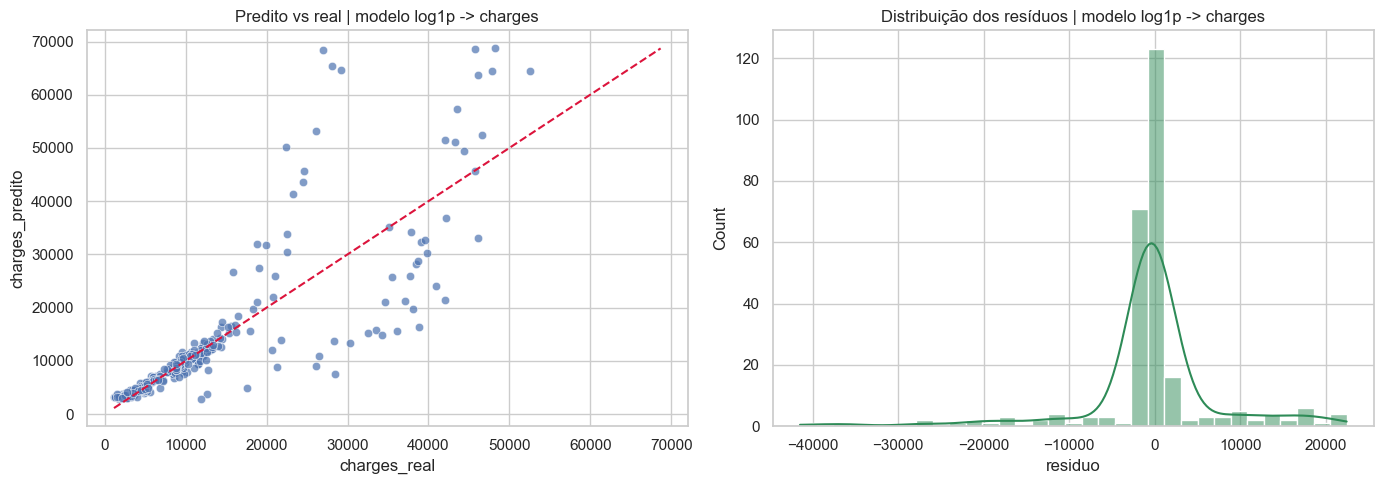

In [10]:
log_predictions = pd.DataFrame({
    "charges_real": y_test,
    "charges_predito": pred_test_log_back,
    "residuo": y_test - pred_test_log_back
}).reset_index(drop=True)

display(log_predictions.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=log_predictions, x="charges_real", y="charges_predito", ax=axes[0], alpha=0.7)
min_log = min(log_predictions["charges_real"].min(), log_predictions["charges_predito"].min())
max_log = max(log_predictions["charges_real"].max(), log_predictions["charges_predito"].max())
axes[0].plot([min_log, max_log], [min_log, max_log], color="crimson", linestyle="--")
axes[0].set_title("Predito vs real | modelo log1p -> charges")

sns.histplot(log_predictions["residuo"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Distribuição dos resíduos | modelo log1p -> charges")

plt.tight_layout()
plt.show()

## 4. Comparação final dos modelos

A comparação abaixo coloca os dois candidatos na mesma escala de negócio: `charges`.


In [11]:
comparison = pd.concat([
    raw_metrics.query("split == 'test'"),
    log_back_metrics.query("split == 'test'")
], ignore_index=True)

comparison = comparison[["modelo", "split", "escala", "RMSE", "MAE", "R2"]].sort_values(by="RMSE")
display(comparison)

log_scale_test = log_metrics.query("split == 'test'")[["modelo", "split", "escala", "RMSE", "MAE", "R2"]]
display(log_scale_test)

,modelo,split,escala,RMSE,MAE,R2
0,Linear (charges),test,charges,"5,002.2242","3,592.7740",0.8264
1,Linear (log1p -> charges),test,charges,"7,818.6976","3,841.8216",0.5759


,modelo,split,escala,RMSE,MAE,R2
1,Linear (log1p),test,log1p(charges),0.3768,0.2537,0.8297


In [12]:
coefficient_interpretation = pd.DataFrame([
    {
        "feature": "const",
        "coef_raw": ols_raw.params["const"],
        "coef_log": ols_log.params["const"],
        "leitura": "valor base esperado quando age, bmi e smoker_yes são zero; útil como intercepto, não como perfil realista."
    },
    {
        "feature": "age",
        "coef_raw": ols_raw.params["age"],
        "coef_log": ols_log.params["age"],
        "leitura": "variação média esperada em charges para +1 ano de idade, mantendo bmi e smoker constantes."
    },
    {
        "feature": "bmi",
        "coef_raw": ols_raw.params["bmi"],
        "coef_log": ols_log.params["bmi"],
        "leitura": "variação média esperada em charges para +1 ponto de BMI, mantendo as demais variáveis constantes."
    },
    {
        "feature": "smoker_yes",
        "coef_raw": ols_raw.params["smoker_yes"],
        "coef_log": ols_log.params["smoker_yes"],
        "leitura": "diferença média esperada entre fumantes e não fumantes com mesma idade e mesmo BMI."
    }
])

display(coefficient_interpretation)

,feature,coef_raw,coef_log,leitura
0,const,"-11,132.6907",7.1634,"valor base esperado quando age, bmi e smoker_y..."
1,age,259.0895,0.0347,variação média esperada em charges para +1 ano...
2,bmi,308.6324,0.0089,variação média esperada em charges para +1 pon...
3,smoker_yes,"23,696.6607",1.5403,diferença média esperada entre fumantes e não ...


### Leitura do baseline

- O modelo em `charges` tende a ser mais fácil de comunicar porque seus coeficientes estão na escala monetária original.
- O modelo em `log1p(charges)` tende a respeitar melhor a assimetria observada no EDA, mas precisa ser comparado com cuidado após retornar à escala original.
- Se o melhor critério for **menor RMSE em `charges`**, escolha o modelo que ficar no topo da tabela `comparison`.
- Se houver interesse em melhorar a forma funcional do modelo, o próximo passo natural é testar `bmi_x_smoker`, já sugerido no EDA.
